# LendingClub Credit Risk — Final Scorecard & Business Applications

Builds the final 22-feature scorecard (out-of-time test Gini = 0.3867, beating
LendingClub's own grade/sub_grade/int_rate on the same population — see the
project README for the full feature-selection process and field-by-field
results) and applies it to three business decisions:

1. **Approval cutoffs** — where to draw the line, in dollars
2. **Risk-based pricing** — does our score reveal repricing opportunity within LC's
   existing grades?
3. **Loan-amount / exposure guidance** — how much to lend, by risk tier

Same out-of-time design as every other notebook in this project: train on loans
issued 2007–2015, test on 2016; Individual applications only; no `grade`/
`sub_grade`/`int_rate`/`installment` as **model inputs** (only used below as an
evaluation-only benchmark and pricing context, never fed into the scorecard).

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

path = kagglehub.dataset_download("wordsforthewise/lending-club")
print("Dataset path:", path)

Dataset path: /Users/andreastio/.cache/kagglehub/datasets/wordsforthewise/lending-club/versions/3


## 1. Load & prepare data

In [2]:
usecols = [
    "loan_amnt", "funded_amnt", "total_pymnt", "term", "emp_length",
    "home_ownership", "annual_inc", "verification_status", "issue_d",
    "loan_status", "purpose", "dti", "delinq_2yrs", "inq_last_6mths",
    "fico_range_low", "fico_range_high", "open_acc", "pub_rec", "revol_bal",
    "revol_util", "total_acc", "mort_acc", "pub_rec_bankruptcies",
    "application_type", "acc_open_past_24mths", "bc_open_to_buy",
    "mths_since_recent_bc", "mths_since_recent_inq", "mo_sin_rcnt_rev_tl_op",
    "mo_sin_rcnt_tl", "num_actv_rev_tl", "num_rev_tl_bal_gt_0",
    "num_tl_op_past_12m", "tot_hi_cred_lim", "total_bc_limit",
    "percent_bc_gt_75", "grade", "sub_grade", "int_rate",
]

csv_path = f"{path}/accepted_2007_to_2018Q4.csv.gz"
df = pd.read_csv(csv_path, usecols=usecols, low_memory=False)
print(df.shape)

(2260701, 39)


In [3]:
def parse_emp_length(x):
    if pd.isna(x):
        return np.nan
    if "<" in x:
        return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["term_months"] = df["term"].str.extract(r"(\d+)").astype(float)
df["revol_util"] = df["revol_util"].astype(str).str.rstrip("%").replace("nan", np.nan).astype(float)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["emp_length_years"] = df["emp_length"].apply(parse_emp_length)
df["fico_mid"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
df["loan_to_income"] = df["loan_amnt"] / df["annual_inc"].replace(0, np.nan)

df = df[df["application_type"] == "Individual"].copy()

bad_statuses = ["Charged Off", "Default"]
good_statuses = ["Fully Paid"]
resolved = df[df["loan_status"].isin(bad_statuses + good_statuses)].copy()
resolved["is_default"] = resolved["loan_status"].isin(bad_statuses).astype(int)
resolved["net_profit"] = resolved["total_pymnt"] - resolved["funded_amnt"]
resolved["realized_return"] = resolved["net_profit"] / resolved["funded_amnt"]

train = resolved[resolved["issue_d"] < "2016-01-01"].copy()
test = resolved[(resolved["issue_d"] >= "2016-01-01") & (resolved["issue_d"] < "2017-01-01")].copy()

train_default_rate = train["is_default"].mean()
test_default_rate = test["is_default"].mean()
print(f"Train (issued < 2016): {len(train):,} loans, default rate {train_default_rate:.2%}")
print(f"Test  (issued 2016)  : {len(test):,} loans, default rate {test_default_rate:.2%}")

Train (issued < 2016): 826,205 loans, default rate 18.42%
Test  (issued 2016)  : 287,819 loans, default rate 23.26%


## 2. FICO as a rolling-percentile feature

Same construction used throughout this project (see the README for the full rationale).

In [4]:
K_MONTHS = 6

df["issue_month"] = df["issue_d"].dt.to_period("M")

month_ficos = (
    df.dropna(subset=["fico_mid"])
    .groupby("issue_month")["fico_mid"]
    .apply(lambda s: np.sort(s.values))
    .sort_index()
)
all_months = month_ficos.index.tolist()

reference_by_month = {}
for i, m in enumerate(all_months):
    ref_months = all_months[max(0, i - K_MONTHS):i]
    if ref_months:
        reference_by_month[m] = np.sort(np.concatenate([month_ficos[mm] for mm in ref_months]))
    else:
        reference_by_month[m] = month_ficos[m]


def _percentile_within_group(group):
    ref = reference_by_month.get(group.name, np.array([]))
    if len(ref) == 0:
        return pd.Series(np.nan, index=group.index)
    idx = np.searchsorted(ref, group["fico_mid"].values, side="left")
    return pd.Series(idx / len(ref), index=group.index)


df["fico_percentile"] = df.groupby("issue_month", group_keys=False).apply(_percentile_within_group)
df.loc[df["fico_mid"].isna(), "fico_percentile"] = np.nan

train["fico_percentile"] = df.loc[train.index, "fico_percentile"]
test["fico_percentile"] = df.loc[test.index, "fico_percentile"]

## 3. WOE-bin the validated 22-feature set

This is the feature set locked in by the systematic sweep documented in the
README — no re-screening here, just fitting bins on train and checking IV
lands where expected as a consistency check.

In [5]:
NUMERIC_FEATURES = [
    "loan_to_income", "fico_percentile", "acc_open_past_24mths", "dti",
    "num_tl_op_past_12m", "bc_open_to_buy", "mo_sin_rcnt_tl", "total_bc_limit",
    "tot_hi_cred_lim", "mths_since_recent_inq", "loan_amnt",
    "mo_sin_rcnt_rev_tl_op", "percent_bc_gt_75", "num_actv_rev_tl",
    "num_rev_tl_bal_gt_0", "annual_inc", "mths_since_recent_bc", "mort_acc",
    "revol_util",
]
CATEGORICAL_FEATURES = ["term_months", "verification_status", "home_ownership"]
SELECTED_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

MISSING_LABEL = "Missing"
RARE_LABEL = "Other"
EPS = 0.5


def fit_numeric_bins(series, n_bins=10):
    valid = series.dropna()
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(valid.quantile(quantiles).values)
    edges[0] = -np.inf
    edges[-1] = np.inf
    if len(edges) < 3:
        edges = np.array([-np.inf, np.inf])
    return edges


def apply_numeric_bins(series, edges):
    binned = pd.cut(series, bins=edges, include_lowest=True)
    return binned.astype("object").where(series.notna(), MISSING_LABEL)


def fit_categorical_groups(series, min_share=0.01):
    freq = series.value_counts(normalize=True, dropna=False)
    return set(freq[freq >= min_share].index)


def apply_categorical_groups(series, keep):
    return series.where(series.isin(keep), RARE_LABEL).fillna(MISSING_LABEL)


def compute_woe_table(binned_train, target_train):
    tab = pd.DataFrame({"bin": binned_train, "target": target_train})
    grp = tab.groupby("bin", observed=True)["target"].agg(["count", "sum"])
    grp.columns = ["n", "bad"]
    grp["good"] = grp["n"] - grp["bad"]
    total_good, total_bad = grp["good"].sum(), grp["bad"].sum()
    grp["good_rate"] = (grp["good"] + EPS) / (total_good + EPS * len(grp))
    grp["bad_rate"] = (grp["bad"] + EPS) / (total_bad + EPS * len(grp))
    grp["woe"] = np.log(grp["good_rate"] / grp["bad_rate"])
    grp["iv_component"] = (grp["good_rate"] - grp["bad_rate"]) * grp["woe"]
    return grp


bin_edges, cat_groups, woe_tables, iv_summary = {}, {}, {}, {}

for feat in NUMERIC_FEATURES:
    edges = fit_numeric_bins(train[feat])
    bin_edges[feat] = edges
    binned_train = apply_numeric_bins(train[feat], edges)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

for feat in CATEGORICAL_FEATURES:
    keep = fit_categorical_groups(train[feat])
    cat_groups[feat] = keep
    binned_train = apply_categorical_groups(train[feat], keep)
    woe_tab = compute_woe_table(binned_train, train["is_default"])
    woe_tables[feat] = woe_tab
    iv_summary[feat] = woe_tab["iv_component"].sum()

iv_series = pd.Series(iv_summary).sort_values(ascending=False)
print(iv_series)

term_months              0.240269
loan_to_income           0.125344
fico_percentile          0.109982
acc_open_past_24mths     0.083348
dti                      0.074900
num_tl_op_past_12m       0.058232
bc_open_to_buy           0.055236
verification_status      0.051346
mo_sin_rcnt_tl           0.042511
total_bc_limit           0.041040
tot_hi_cred_lim          0.040045
mths_since_recent_inq    0.039566
loan_amnt                0.036872
mo_sin_rcnt_rev_tl_op    0.032725
percent_bc_gt_75         0.032510
num_actv_rev_tl          0.031542
num_rev_tl_bal_gt_0      0.031464
annual_inc               0.031302
mths_since_recent_bc     0.029484
mort_acc                 0.027173
revol_util               0.022288
home_ownership           0.020870
dtype: float64


## 4. Fit logistic regression, check coefficient signs

In [6]:
def transform_to_woe(data, features):
    out = pd.DataFrame(index=data.index)
    for feat in features:
        woe_tab = woe_tables[feat]
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        out[feat] = binned.map(woe_tab["woe"]).fillna(0.0)
    return out

X_train = transform_to_woe(train, SELECTED_FEATURES)
X_test = transform_to_woe(test, SELECTED_FEATURES)
y_train = train["is_default"].values
y_test = test["is_default"].values

model = LogisticRegression(solver="lbfgs")
model.fit(X_train, y_train)

coef_table = pd.Series(model.coef_[0], index=SELECTED_FEATURES).sort_values()
print("Intercept:", model.intercept_[0])
print(coef_table)
bad_sign = coef_table[coef_table > 0]
print("Unexpected positive coefficients:" if len(bad_sign) else "All negative as expected.", list(bad_sign.index))

Intercept: -1.491405254030018
home_ownership          -0.994294
term_months             -0.951450
fico_percentile         -0.686024
loan_to_income          -0.586113
acc_open_past_24mths    -0.560194
mths_since_recent_inq   -0.429071
dti                     -0.398380
bc_open_to_buy          -0.385038
annual_inc              -0.347524
mths_since_recent_bc    -0.339019
num_tl_op_past_12m      -0.302847
mort_acc                -0.253344
verification_status     -0.252895
mo_sin_rcnt_tl          -0.204876
total_bc_limit          -0.177692
tot_hi_cred_lim         -0.086405
num_rev_tl_bal_gt_0     -0.080902
revol_util              -0.059272
num_actv_rev_tl         -0.038128
percent_bc_gt_75         0.033879
loan_amnt                0.288837
mo_sin_rcnt_rev_tl_op    0.372280
dtype: float64
Unexpected positive coefficients: ['percent_bc_gt_75', 'loan_amnt', 'mo_sin_rcnt_rev_tl_op']


## 5. Out-of-sample performance & consistency check

In [7]:
def ks_statistic(y_true, y_score):
    order = np.argsort(y_score)
    y_true_sorted = np.array(y_true)[order]
    cum_bad = np.cumsum(y_true_sorted) / y_true_sorted.sum()
    cum_good = np.cumsum(1 - y_true_sorted) / (1 - y_true_sorted).sum()
    return np.max(np.abs(cum_bad - cum_good))


def report_performance(y_true, proba, label):
    auc = roc_auc_score(y_true, proba)
    gini = 2 * auc - 1
    ks = ks_statistic(y_true, proba)
    print(f"{label:>12}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")
    return auc, gini, ks

train_proba = model.predict_proba(X_train)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

train_perf = report_performance(y_train, train_proba, "Train (IS)")
test_perf = report_performance(y_test, test_proba, "Test (OOS)")
print("\nConsistency check target: Train Gini=0.4087, Test Gini=0.3867")

  Train (IS): AUC=0.7044  Gini=0.4087  KS=0.2975
  Test (OOS): AUC=0.6934  Gini=0.3867  KS=0.2771

Consistency check target: Train Gini=0.4087, Test Gini=0.3867


## 6. Points-based scorecard, scoring, and sanity checks

In [8]:
BASE_SCORE, BASE_ODDS, PDO = 600, 50, 20
factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
n_features = len(SELECTED_FEATURES)

scorecard_rows = []
for feat, coef in zip(SELECTED_FEATURES, model.coef_[0]):
    tab = woe_tables[feat]
    for bin_label, row in tab.iterrows():
        points = -(coef * row["woe"] + model.intercept_[0] / n_features) * factor + offset / n_features
        scorecard_rows.append({
            "feature": feat, "bin": bin_label, "n_train": int(row["n"]),
            "bad_rate_train": row["bad"] / row["n"], "woe": row["woe"],
            "points": round(points, 1),
        })
scorecard = pd.DataFrame(scorecard_rows)

def compute_scores(X_woe):
    log_odds_bad = model.intercept_[0] + X_woe.values @ model.coef_[0]
    return offset - factor * log_odds_bad

train["score"] = compute_scores(X_train)
test["score"] = compute_scores(X_test)

def points_lookup(data, features):
    total = pd.Series(0.0, index=data.index)
    for feat in features:
        if feat in NUMERIC_FEATURES:
            binned = apply_numeric_bins(data[feat], bin_edges[feat])
        else:
            binned = apply_categorical_groups(data[feat], cat_groups[feat])
        points_map = scorecard[scorecard["feature"] == feat].set_index("bin")["points"]
        total = total + binned.map(points_map).fillna(0.0)
    return total

sample_idx = train.sample(2000, random_state=0).index
points_check = points_lookup(train.loc[sample_idx], SELECTED_FEATURES)
score_check = pd.Series(compute_scores(X_train.loc[sample_idx]), index=sample_idx)
max_diff = (points_check - score_check).abs().max()
print(f"Max |points-table score - compute_scores()|: {max_diff:.4f}")
assert max_diff < 2.0, "Points table and compute_scores() disagree."

direction_check = train.groupby(pd.qcut(train["score"], 5, duplicates="drop"), observed=True)["is_default"].mean()
assert direction_check.iloc[0] > direction_check.iloc[-1], "Score is inverted."
print("Score direction confirmed: higher score -> lower default rate.")

Max |points-table score - compute_scores()|: 0.5218
Score direction confirmed: higher score -> lower default rate.


## 7. Benchmark: our scorecard vs. LendingClub's own grade/sub_grade/int_rate

Evaluation-only — these fields were never used as model inputs.

In [9]:
grade_order = {g: i + 1 for i, g in enumerate("ABCDEFG")}
sub_grade_order = {f"{g}{n}": i + 1 for i, (g, n) in enumerate(
    (g, n) for g in "ABCDEFG" for n in range(1, 6)
)}
test["grade_ordinal"] = test["grade"].map(grade_order)
test["sub_grade_ordinal"] = test["sub_grade"].map(sub_grade_order)

for label, col in [("LC grade", "grade_ordinal"), ("LC sub_grade", "sub_grade_ordinal"), ("LC int_rate", "int_rate")]:
    valid = test[col].notna()
    auc = roc_auc_score(y_test[valid.values], test.loc[valid, col])
    gini = 2 * auc - 1
    ks = ks_statistic(y_test[valid.values], test.loc[valid, col].values)
    print(f"{label:>14}: AUC={auc:.4f}  Gini={gini:.4f}  KS={ks:.4f}")

our_auc, our_gini, our_ks = test_perf
our_label = "Our scorecard"
print(f"{our_label:>14}: AUC={our_auc:.4f}  Gini={our_gini:.4f}  KS={our_ks:.4f}")

      LC grade: AUC=0.6818  Gini=0.3635  KS=0.2726
  LC sub_grade: AUC=0.6912  Gini=0.3824  KS=0.2761


   LC int_rate: AUC=0.6912  Gini=0.3823  KS=0.2776
 Our scorecard: AUC=0.6934  Gini=0.3867  KS=0.2771


## 8. Business application 1 — Approval cutoff strategy

Using realized historical cash flow (`total_pymnt - funded_amnt`) as ground truth,
not an assumed loss rate.

In [10]:
cutoffs = np.quantile(test["score"], np.linspace(0.0, 0.97, 40))
rows = []
for c in cutoffs:
    approved = test[test["score"] >= c]
    if len(approved) == 0:
        continue
    rows.append({
        "cutoff": c,
        "approval_rate": len(approved) / len(test),
        "bad_rate_approved": approved["is_default"].mean(),
        "total_profit": approved["net_profit"].sum(),
    })
strategy_curve = pd.DataFrame(rows)
baseline_profit = test["net_profit"].sum()
best_row = strategy_curve.loc[strategy_curve["total_profit"].idxmax()]
best_cutoff = best_row["cutoff"]
best_approval_rate = best_row["approval_rate"]
best_bad_rate = best_row["bad_rate_approved"]
best_total_profit = best_row["total_profit"]
profit_swing = best_total_profit - baseline_profit

print(f"Accept-all (no cutoff) baseline profit: ${baseline_profit:,.0f}")
print(f"Profit-maximizing cutoff: score >= {best_cutoff:.1f}")
print(f"  -> approval rate {best_approval_rate:.1%}, bad rate {best_bad_rate:.1%}, total profit ${best_total_profit:,.0f}")
print(f"  -> ${profit_swing:,.0f} swing vs. accept-all")

# export a coarse 10-point version of the curve for reporting purposes
report_points = strategy_curve.iloc[np.linspace(0, len(strategy_curve) - 1, 10).astype(int)]
print("\nCUTOFF_CURVE_CSV")
print(report_points[["cutoff", "approval_rate", "bad_rate_approved", "total_profit"]].to_csv(index=False))

Accept-all (no cutoff) baseline profit: $-71,483,853
Profit-maximizing cutoff: score >= 534.3
  -> approval rate 52.7%, bad rate 13.9%, total profit $65,835,564
  -> $137,319,417 swing vs. accept-all

CUTOFF_CURVE_CSV
cutoff,approval_rate,bad_rate_approved,total_profit
460.71816783764143,1.0,0.23260451881217015,-71483852.81661546
506.94278883223103,0.9005103902105143,0.20392848323970617,15083784.716790006
517.9953164609492,0.8010242548268183,0.183951420516157,46246446.921344444
526.4976011649159,0.6766648483943034,0.16294664633363629,61717452.48889264
531.8085695507483,0.5771787130106074,0.14742690656922883,65062712.75428662
536.7864591027923,0.47769257762691136,0.13187964128039334,63844109.48104987
543.1505900998214,0.3533331711943965,0.11191197293895531,56632645.38161661
548.9879208194146,0.25384703581070045,0.09523418466507898,45883966.25730693
556.5097654790798,0.15436090042700448,0.073332132889169,32034328.610666968
575.8599352426965,0.030001493994489592,0.03393167342211928,734303

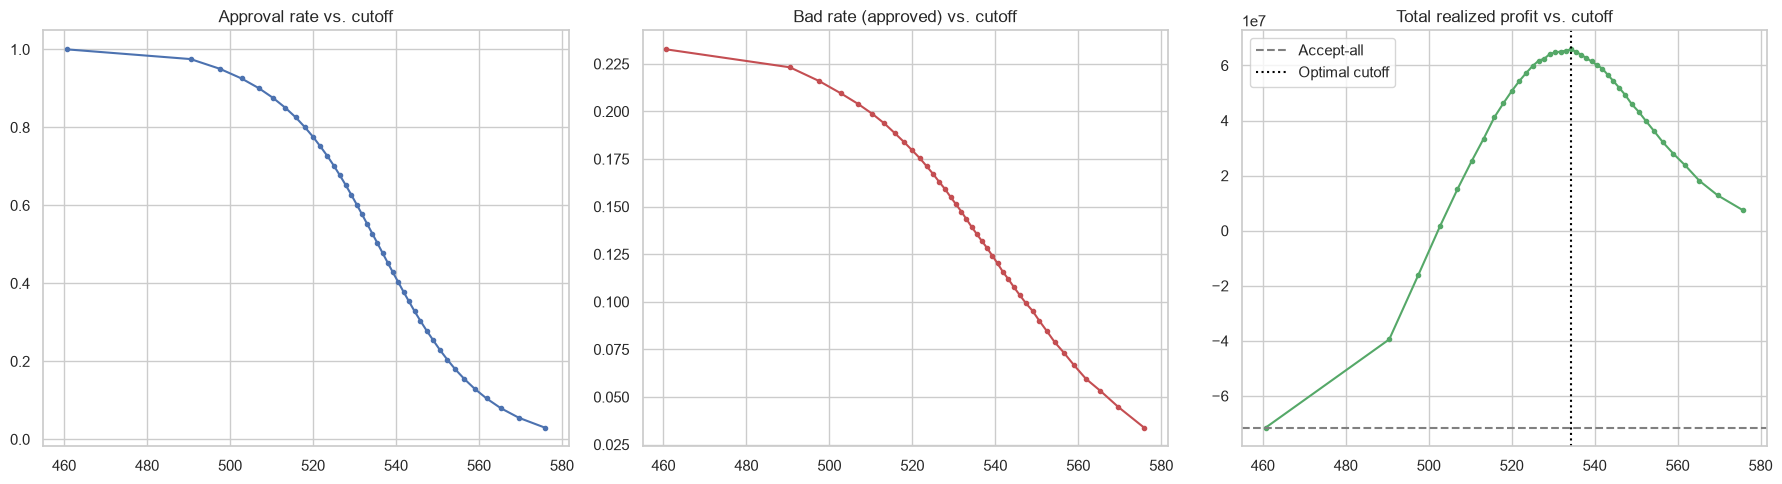

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(strategy_curve["cutoff"], strategy_curve["approval_rate"], marker="o", markersize=3)
axes[0].set_title("Approval rate vs. cutoff")
axes[1].plot(strategy_curve["cutoff"], strategy_curve["bad_rate_approved"], marker="o", markersize=3, color="#C44E52")
axes[1].set_title("Bad rate (approved) vs. cutoff")
axes[2].plot(strategy_curve["cutoff"], strategy_curve["total_profit"], marker="o", markersize=3, color="#55A868")
axes[2].axhline(baseline_profit, linestyle="--", color="grey", label="Accept-all")
axes[2].axvline(best_cutoff, linestyle=":", color="black", label="Optimal cutoff")
axes[2].set_title("Total realized profit vs. cutoff")
axes[2].legend()
plt.tight_layout()
plt.show()

### Conclusion — impact of this cutoff strategy

Approving every applicant in the 2016 test population would have realized a
**$71.5M loss** (real historical cash flow, not an assumption). Applying the
score-based cutoff instead:

| Metric | Accept-all | With cutoff (score ≥ 534.3) |
|---|---|---|
| Approval rate | 100% | 52.7% |
| Bad rate among approved | 23.3% | 13.9% |
| Total realized profit | -$71.5M | **+$65.8M** |

**Net impact: a $137.3M swing** — the difference between a policy that lost
money and one that was solidly profitable, achieved by declining roughly the
worst-scoring 47% of applicants. This is the single highest-leverage decision
in this analysis: it doesn't require repricing or new products, just applying
the scorecard to the accept/decline line LendingClub already draws.

**How to read this for deployment:** the cutoff was chosen by scanning score
thresholds for the one that maximizes total realized profit on this out-of-time
population — it is a starting point for policy discussion, not a fixed rule.
Before production use, stress-test it against a downturn scenario and layer in
funding/servicing cost, both excluded here (see the caveats in the final
summary).

## 9. Business application 2 — Risk-based pricing: is there repricing opportunity within LC's grades?

LendingClub prices primarily by grade/sub-grade. If our score meaningfully splits
default risk *within* a single LC grade, that's evidence of under-priced risk
differentiation — good-in-grade borrowers subsidizing bad-in-grade ones.

In [12]:
test["score_tercile_in_grade"] = test.groupby("grade")["score"].transform(
    lambda s: pd.qcut(s, 3, labels=["Lower third", "Middle third", "Upper third"], duplicates="drop")
)

pricing_table = test.groupby(["grade", "score_tercile_in_grade"], observed=True).agg(
    n=("is_default", "size"),
    bad_rate=("is_default", "mean"),
    avg_int_rate=("int_rate", "mean"),
    avg_realized_return=("realized_return", "mean"),
).reset_index()
pricing_table = pricing_table.sort_values(["grade", "score_tercile_in_grade"])
pricing_table

,grade,score_tercile_in_grade,n,bad_rate,avg_int_rate,avg_realized_return
0,A,Lower third,16156,0.114942,7.310295,0.025626
1,A,Middle third,16155,0.065243,6.890178,0.046629
2,A,Upper third,16155,0.036707,6.328878,0.051737
3,B,Lower third,29211,0.220636,10.450327,-0.004636
4,B,Middle third,29210,0.153920,10.210155,0.028937
5,B,Upper third,29211,0.109753,9.981982,0.046220
6,C,Lower third,28329,0.340534,13.971442,-0.062325
7,C,Middle third,28328,0.251271,13.738450,-0.001401
8,C,Upper third,28329,0.191182,13.579631,0.026462
9,D,Lower third,13256,0.444176,18.514510,-0.114156


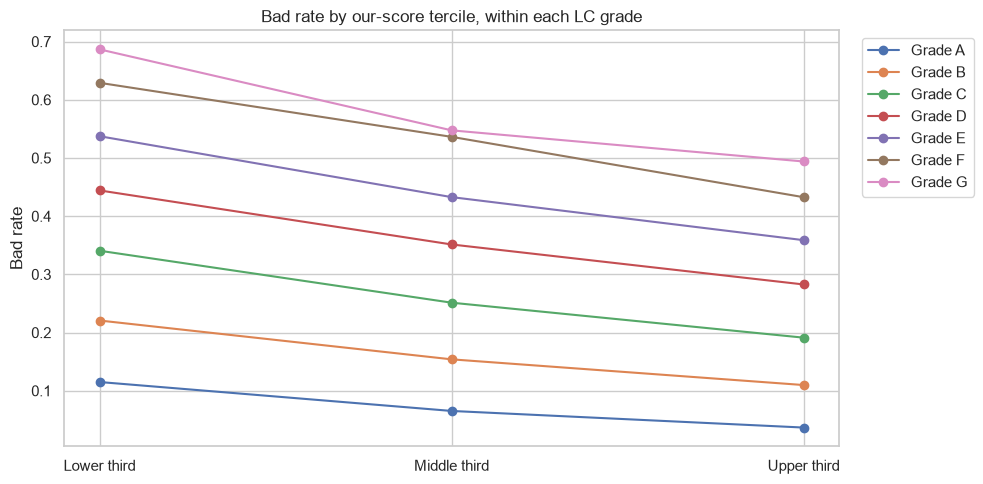

Bad-rate spread (Lower third minus Upper third) within each grade:
score_tercile_in_grade    spread
grade                           
A                      -0.078235
B                      -0.110883
C                      -0.149352
D                      -0.161587
E                      -0.178607
F                      -0.196529
G                      -0.192661


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for grade in sorted(test["grade"].dropna().unique()):
    sub = pricing_table[pricing_table["grade"] == grade]
    if len(sub) == 3:
        ax.plot(sub["score_tercile_in_grade"].astype(str), sub["bad_rate"], marker="o", label=f"Grade {grade}")
ax.set_ylabel("Bad rate")
ax.set_title("Bad rate by our-score tercile, within each LC grade")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Quantify the within-grade dispersion directly
dispersion = pricing_table.pivot(index="grade", columns="score_tercile_in_grade", values="bad_rate")
dispersion["spread"] = dispersion.get("Upper third", np.nan) - dispersion.get("Lower third", np.nan)
print("Bad-rate spread (Lower third minus Upper third) within each grade:")
print(dispersion[["spread"]].dropna())

## 10. Business application 3 — Loan-amount / exposure guidance by risk tier

How much to lend, not just whether to lend. Bad rate and realized dollar loss by
loan-amount tercile, within each score quintile.

In [14]:
test["score_quintile"] = pd.qcut(test["score"], 5, labels=["Q1 (worst)", "Q2", "Q3", "Q4", "Q5 (best)"], duplicates="drop")
test["loan_amnt_tercile"] = test.groupby("score_quintile", observed=True)["loan_amnt"].transform(
    lambda s: pd.qcut(s, 3, labels=["Small", "Medium", "Large"], duplicates="drop")
)

exposure_table = test.groupby(["score_quintile", "loan_amnt_tercile"], observed=True).agg(
    n=("is_default", "size"),
    avg_loan_amnt=("loan_amnt", "mean"),
    bad_rate=("is_default", "mean"),
    total_net_profit=("net_profit", "sum"),
    profit_per_loan=("net_profit", "mean"),
).reset_index()
exposure_table

,score_quintile,loan_amnt_tercile,n,avg_loan_amnt,bad_rate,total_net_profit,profit_per_loan
0,Q1 (worst),Small,19463,9395.366850,0.410060,-1.669733e+07,-857.901370
1,Q1 (worst),Medium,19846,16768.527663,0.434143,-3.981985e+07,-2006.442248
2,Q1 (worst),Large,18255,27395.256094,0.439989,-6.130414e+07,-3358.210673
3,Q2,Small,19198,5561.445203,0.279925,-1.446943e+06,-75.369448
4,Q2,Medium,19222,11682.772344,0.280304,-4.222724e+06,-219.681804
5,Q2,Large,19144,23819.124791,0.287087,-1.264619e+07,-660.582508
6,Q3,Small,21698,5296.246198,0.206471,1.832286e+06,84.444922
7,Q3,Medium,18637,11531.048452,0.210603,2.585320e+06,138.719758
8,Q3,Large,17228,23937.888902,0.226027,2.113553e+05,12.268126
9,Q4,Small,21514,5223.808915,0.150786,3.535432e+06,164.331695


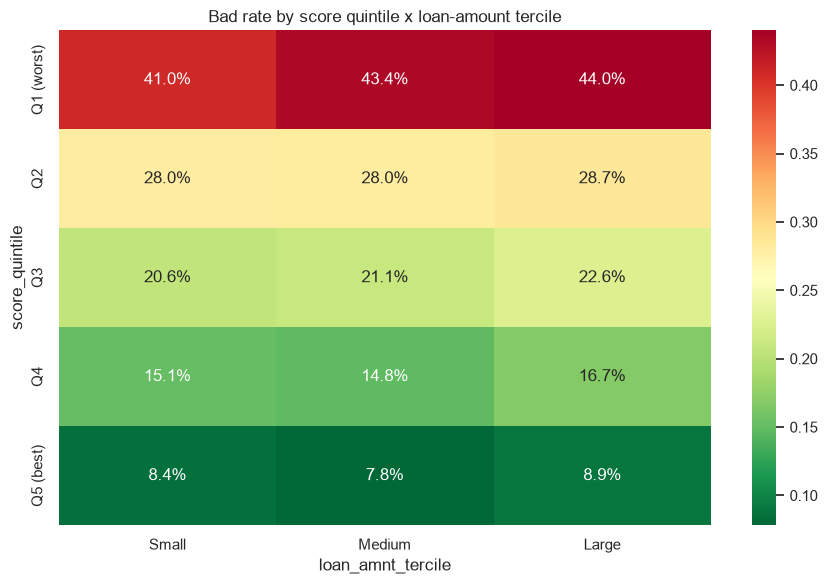

Historically loss-making tier x loan-amount combinations:
  score_quintile loan_amnt_tercile      n  bad_rate  profit_per_loan
0     Q1 (worst)             Small  19463  0.410060      -857.901370
1     Q1 (worst)            Medium  19846  0.434143     -2006.442248
2     Q1 (worst)             Large  18255  0.439989     -3358.210673
3             Q2             Small  19198  0.279925       -75.369448
4             Q2            Medium  19222  0.280304      -219.681804
5             Q2             Large  19144  0.287087      -660.582508


In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
heat_data = exposure_table.pivot(index="score_quintile", columns="loan_amnt_tercile", values="bad_rate")
sns.heatmap(heat_data, annot=True, fmt=".1%", cmap="RdYlGn_r", ax=ax)
ax.set_title("Bad rate by score quintile x loan-amount tercile")
plt.tight_layout()
plt.show()

# flag any tier x amount combos that are net money-losers historically
losers = exposure_table[exposure_table["profit_per_loan"] < 0]
print("Historically loss-making tier x loan-amount combinations:")
print(losers[["score_quintile", "loan_amnt_tercile", "n", "bad_rate", "profit_per_loan"]])

## 11. Summary

- **Final scorecard**: 22 features, out-of-time test Gini = 0.3867 (see Section 5),
  beating LendingClub's own grade/sub_grade/int_rate on the same population
  (Section 7).
- **Approval cutoffs** (Section 8): the profit-maximizing cutoff and its dollar
  impact vs. an accept-all policy are printed above.
- **Pricing** (Section 9): within-grade bad-rate spread by score tercile shows
  whether LC's current grade-based pricing is leaving risk-based repricing
  opportunity on the table.
- **Loan-amount guidance** (Section 10): the heatmap and loss-making combinations
  above identify where dollar exposure should be capped, independent of the
  accept/decline decision itself.
- All of the above uses realized historical cash flow, is validated out-of-time,
  and inherits every leakage-avoidance and vintage-missingness precaution
  documented in this notebook and the project README.